<a href="https://colab.research.google.com/github/Prarthana-06/CODESOFT/blob/main/sms_Spam_Classifier_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!pip install gensim wordcloud -q

import warnings, re, string, os, io
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
for pkg in ['stopwords', 'punkt', 'punkt_tab', 'wordnet']:
    nltk.download(pkg, quiet=True)
from nltk.corpus   import stopwords
from nltk.stem     import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes              import MultinomialNB, ComplementNB
from sklearn.linear_model             import LogisticRegression
from sklearn.svm                      import LinearSVC
from sklearn.calibration              import CalibratedClassifierCV
from sklearn.ensemble                 import VotingClassifier
from sklearn.pipeline                 import Pipeline
from sklearn.model_selection          import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics                  import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
from sklearn.preprocessing import LabelEncoder
from gensim.models import Word2Vec
import joblib

print(' All libraries loaded.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 35.3 MB/s eta 0:00:00
 All libraries loaded.


In [2]:

from google.colab import files
print('Please upload spam.csv')
uploaded = files.upload()
fname    = list(uploaded.keys())[0]
df_raw   = pd.read_csv(io.BytesIO(uploaded[fname]), encoding='latin-1')


df = df_raw[['v1', 'v2']].copy()
df.columns = ['label', 'message']
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])


STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOP_WORDS and len(t) > 1]
    return ' '.join(tokens)

df['clean'] = df['message'].apply(preprocess)

# ── 2D · Train/test split ─────────────────────────────────────────────────────
X_raw   = df['clean'].values
y       = df['label_enc'].values
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y)

# ── 2E · TF-IDF features ──────────────────────────────────────────────────────
tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=8000, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf  = tfidf.transform(X_test_raw)

# ── 2F · Word2Vec features ────────────────────────────────────────────────────
corpus  = [t.split() for t in df['clean']]
w2v     = Word2Vec(sentences=corpus, vector_size=100, window=5,
                   min_count=2, workers=4, epochs=15, sg=0)

def avg_w2v(tokens, model, size=100):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

X_train_w2v = np.array([avg_w2v(t.split(), w2v) for t in X_train_raw])
X_test_w2v  = np.array([avg_w2v(t.split(), w2v) for t in X_test_raw])


print(f'\n Setup complete!')
print(f'   Total messages : {len(df)}')
print(f'   Ham            : {(df.label=="ham").sum()}')
print(f'   Spam           : {(df.label=="spam").sum()}')
print(f'   Train size     : {len(X_train_raw)}')
print(f'   Test  size     : {len(X_test_raw)}')
print(f'   TF-IDF shape   : {X_train_tfidf.shape}')
print(f'   Word2Vec shape : {X_train_w2v.shape}')

Please upload spam.csv


Saving spam.csv to spam.csv

 Setup complete!
   Total messages : 5169
   Ham            : 4516
   Spam           : 653
   Train size     : 4135
   Test  size     : 1034
   TF-IDF shape   : (4135, 8000)
   Word2Vec shape : (4135, 100)


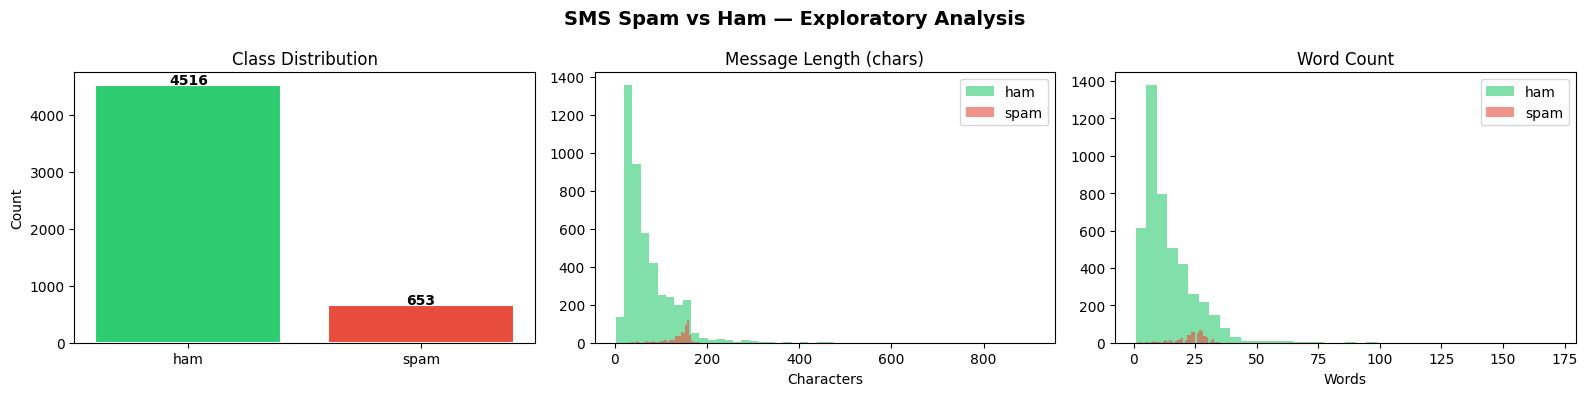


Average stats by class:
       msg_len  word_count
label                     
ham       70.5        14.1
spam     137.9        23.7


In [3]:
df['msg_len']    = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('SMS Spam vs Ham — Exploratory Analysis', fontsize=14, fontweight='bold')


counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=['#2ecc71','#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+20, str(v), ha='center', fontweight='bold')


for lbl, col in [('ham','#2ecc71'), ('spam','#e74c3c')]:
    axes[1].hist(df[df['label']==lbl]['msg_len'],
                 bins=50, alpha=0.6, label=lbl, color=col)
axes[1].set_title('Message Length (chars)')
axes[1].set_xlabel('Characters'); axes[1].legend()


for lbl, col in [('ham','#2ecc71'), ('spam','#e74c3c')]:
    axes[2].hist(df[df['label']==lbl]['word_count'],
                 bins=40, alpha=0.6, label=lbl, color=col)
axes[2].set_title('Word Count')
axes[2].set_xlabel('Words'); axes[2].legend()

plt.tight_layout()
plt.show()

print('\nAverage stats by class:')
print(df.groupby('label')[['msg_len','word_count']].mean().round(1))

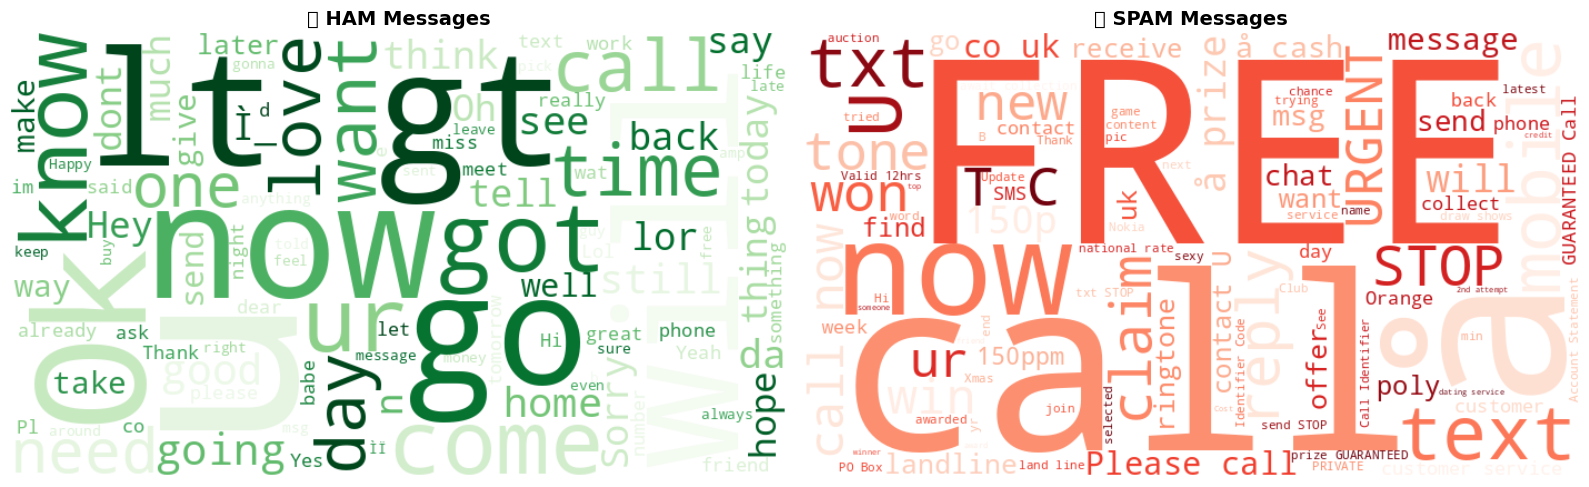

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, lbl, cmap, title in [
    (axes[0], 'ham',  'Greens', '✅ HAM Messages'),
    (axes[1], 'spam', 'Reds',   '🚫 SPAM Messages')
]:
    text = ' '.join(df[df['label']==lbl]['message'])
    wc   = WordCloud(width=700, height=400, background_color='white',
                     colormap=cmap, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
results = []

def evaluate(name, clf, Xtr, Xte, ytr, yte, feat):
    clf.fit(Xtr, ytr)
    ypred = clf.predict(Xte)
    yscore = (clf.predict_proba(Xte)[:,1]
              if hasattr(clf,'predict_proba')
              else clf.decision_function(Xte))
    row = dict(
        Model=name, Features=feat,
        Accuracy = accuracy_score(yte,ypred)*100,
        Precision= precision_score(yte,ypred,zero_division=0)*100,
        Recall   = recall_score(yte,ypred)*100,
        F1       = f1_score(yte,ypred)*100,
        AUC      = roc_auc_score(yte,yscore)*100
    )
    results.append(row)
    print(f"\n{'─'*54}")
    print(f"  {name}  [{feat}]")
    print(f"{'─'*54}")
    print(f"  Acc {row['Accuracy']:.2f}%  Prec {row['Precision']:.2f}%"
          f"  Rec {row['Recall']:.2f}%  F1 {row['F1']:.2f}%  AUC {row['AUC']:.2f}%")
    print(classification_report(yte, ypred,
          target_names=['Ham','Spam'], zero_division=0))
    return clf


evaluate('Complement NB',    ComplementNB(alpha=0.3),
         X_train_tfidf, X_test_tfidf, y_train, y_test, 'TF-IDF')
evaluate('Multinomial NB',   MultinomialNB(alpha=0.5),
         X_train_tfidf, X_test_tfidf, y_train, y_test, 'TF-IDF')

# ── Logistic Regression ───────────────────────────────────────────────────────
evaluate('Logistic Regression', LogisticRegression(C=5, max_iter=300),
         X_train_tfidf, X_test_tfidf, y_train, y_test, 'TF-IDF')
evaluate('Logistic Regression', LogisticRegression(C=5, max_iter=300),
         X_train_w2v,   X_test_w2v,   y_train, y_test, 'Word2Vec')

# ── SVM ───────────────────────────────────────────────────────────────────────
evaluate('SVM (LinearSVC)', CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000)),
         X_train_tfidf, X_test_tfidf, y_train, y_test, 'TF-IDF')
evaluate('SVM (LinearSVC)', CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000)),
         X_train_w2v,   X_test_w2v,   y_train, y_test, 'Word2Vec')

# ── Ensemble ──────────────────────────────────────────────────────────────────
ensemble = VotingClassifier(estimators=[
    ('cnb', ComplementNB(alpha=0.3)),
    ('lr',  LogisticRegression(C=5, max_iter=300)),
    ('svm', CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000)))
], voting='soft')
evaluate('Ensemble (NB+LR+SVM)', ensemble,
         X_train_tfidf, X_test_tfidf, y_train, y_test, 'TF-IDF')

print('\n✅ All models trained!')


──────────────────────────────────────────────────────
  Complement NB  [TF-IDF]
──────────────────────────────────────────────────────
  Acc 97.49%  Prec 89.47%  Rec 90.84%  F1 90.15%  AUC 99.04%
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99       903
        Spam       0.89      0.91      0.90       131

    accuracy                           0.97      1034
   macro avg       0.94      0.95      0.94      1034
weighted avg       0.98      0.97      0.97      1034


──────────────────────────────────────────────────────
  Multinomial NB  [TF-IDF]
──────────────────────────────────────────────────────
  Acc 97.20%  Prec 99.04%  Rec 78.63%  F1 87.66%  AUC 98.82%
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       903
        Spam       0.99      0.79      0.88       131

    accuracy                           0.97      1034
   macro avg       0.98      0.89      0.93      1034
weig

In [6]:
res_df = pd.DataFrame(results).round(2).sort_values('F1', ascending=False)
res_df.reset_index(drop=True, inplace=True)
print('\n📊 MODEL COMPARISON')
print('='*72)
print(res_df.to_string(index=False))


📊 MODEL COMPARISON
               Model Features  Accuracy  Precision  Recall    F1   AUC
     SVM (LinearSVC)   TF-IDF     97.97      93.65   90.08 91.83 99.64
Ensemble (NB+LR+SVM)   TF-IDF     97.87      95.04   87.79 91.27 99.70
       Complement NB   TF-IDF     97.49      89.47   90.84 90.15 99.04
 Logistic Regression   TF-IDF     97.29      97.25   80.92 88.33 99.57
      Multinomial NB   TF-IDF     97.20      99.04   78.63 87.66 98.82
     SVM (LinearSVC) Word2Vec     95.65      89.09   74.81 81.33 98.04
 Logistic Regression Word2Vec     95.65      89.81   74.05 81.17 97.44


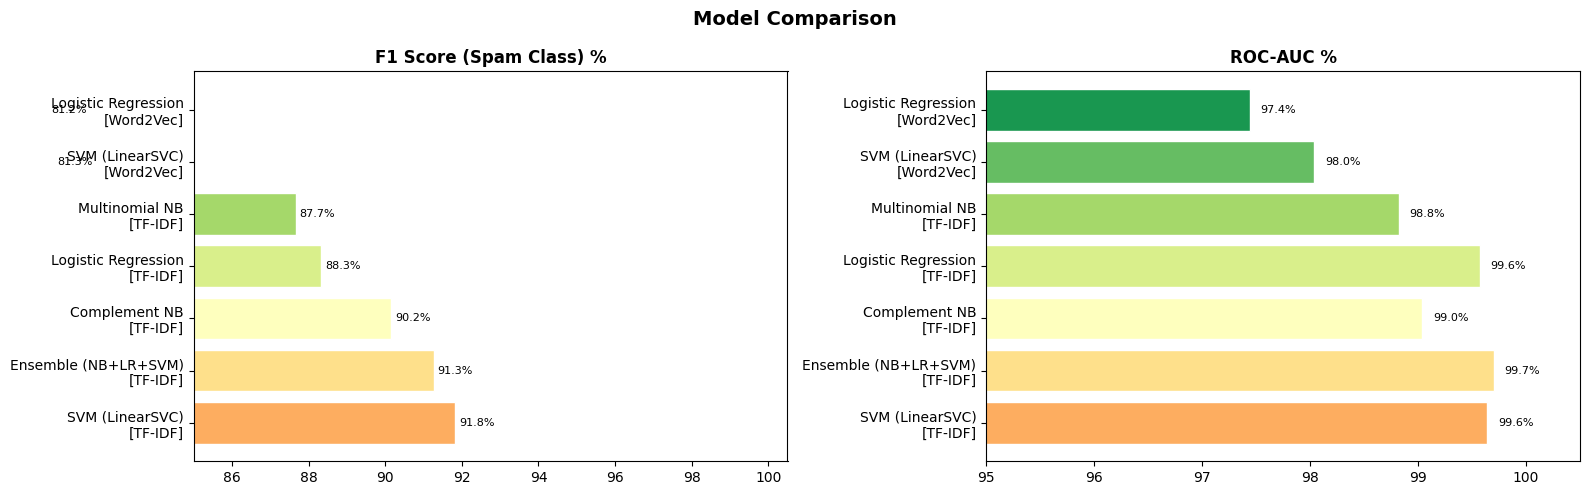

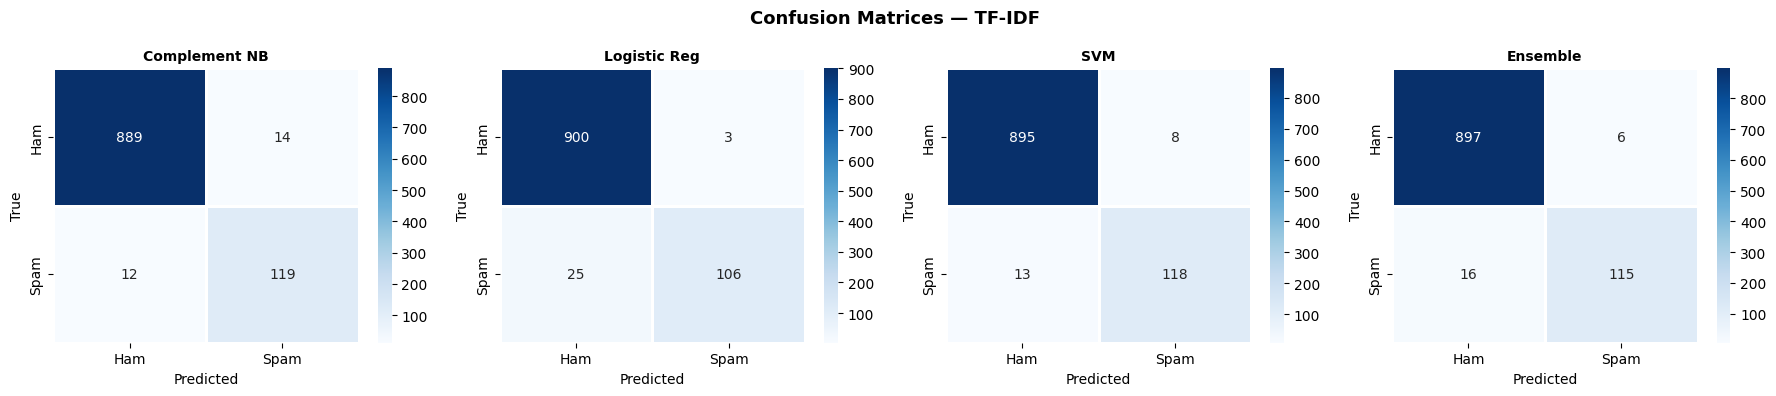

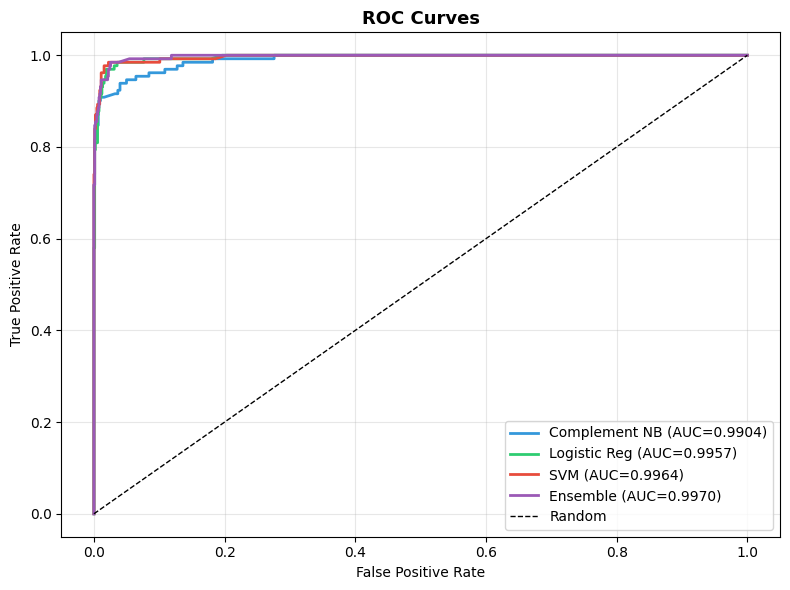

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(res_df)))
labels = [f"{r['Model']}\n[{r['Features']}]" for _,r in res_df.iterrows()]

for ax, metric, xlim, title in [
    (axes[0], 'F1',  85, 'F1 Score (Spam Class) %'),
    (axes[1], 'AUC', 95, 'ROC-AUC %')
]:
    ax.barh(labels, res_df[metric], color=colors, edgecolor='white')
    ax.set_xlim(xlim, 100.5)
    ax.set_title(title, fontweight='bold')
    for bar, val in zip(ax.patches, res_df[metric]):
        ax.text(val+0.1, bar.get_y()+bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=8)
plt.tight_layout(); plt.show()


cm_models = [
    ('Complement NB',    ComplementNB(alpha=0.3)),
    ('Logistic Reg',     LogisticRegression(C=5, max_iter=300)),
    ('SVM',              CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000))),
    ('Ensemble',         VotingClassifier(estimators=[
        ('cnb', ComplementNB(alpha=0.3)),
        ('lr',  LogisticRegression(C=5, max_iter=300)),
        ('svm', CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000)))
    ], voting='soft'))
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Confusion Matrices — TF-IDF', fontsize=13, fontweight='bold')
for ax, (name, clf) in zip(axes, cm_models):
    clf.fit(X_train_tfidf, y_train)
    cm = confusion_matrix(y_test, clf.predict(X_test_tfidf))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'],
                linewidths=1, linecolor='white')
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout(); plt.show()

# ── ROC curves ────────────────────────────────────────────────────────────────
roc_clfs = [
    ('Complement NB',    ComplementNB(alpha=0.3)),
    ('Logistic Reg',     LogisticRegression(C=5, max_iter=300)),
    ('SVM',              CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000))),
    ('Ensemble',         VotingClassifier(estimators=[
        ('cnb', ComplementNB(alpha=0.3)),
        ('lr',  LogisticRegression(C=5, max_iter=300)),
        ('svm', CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000)))
    ], voting='soft'))
]
roc_colors = ['#3498db','#2ecc71','#e74c3c','#9b59b6']

plt.figure(figsize=(8, 6))
for (name, clf), col in zip(roc_clfs, roc_colors):
    clf.fit(X_train_tfidf, y_train)
    scores = clf.predict_proba(X_test_tfidf)[:,1]
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc = roc_auc_score(y_test, scores)
    plt.plot(fpr, tpr, color=col, lw=2, label=f'{name} (AUC={auc:.4f})')
plt.plot([0,1],[0,1],'k--', lw=1, label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves', fontsize=13, fontweight='bold')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

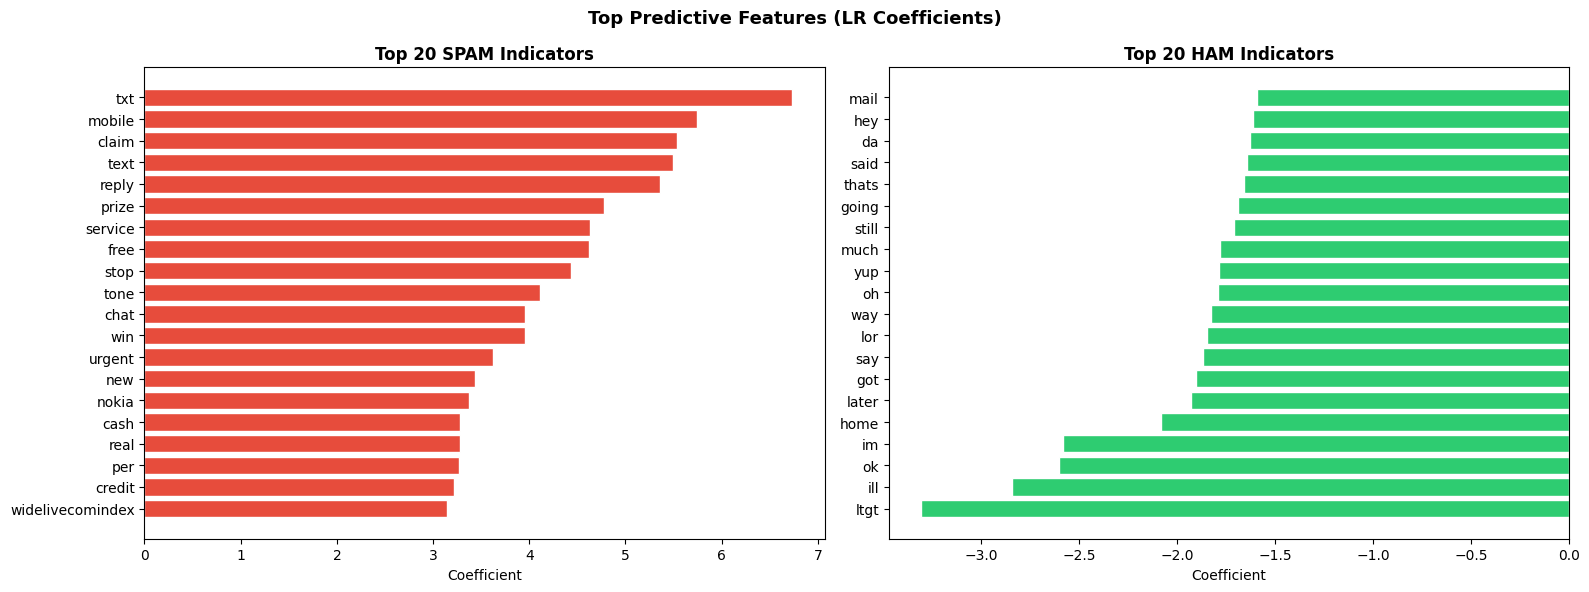

In [8]:
lr = LogisticRegression(C=5, max_iter=300)
lr.fit(X_train_tfidf, y_train)
feature_names = tfidf.get_feature_names_out()
coefs = lr.coef_[0]
N = 20

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top Predictive Features (LR Coefficients)', fontsize=13, fontweight='bold')

top_spam = coefs.argsort()[-N:][::-1]
top_ham  = coefs.argsort()[:N]

axes[0].barh(feature_names[top_spam][::-1], coefs[top_spam][::-1],
             color='#e74c3c', edgecolor='white')
axes[0].set_title('Top 20 SPAM Indicators', fontweight='bold')
axes[0].set_xlabel('Coefficient')

axes[1].barh(feature_names[top_ham], coefs[top_ham],
             color='#2ecc71', edgecolor='white')
axes[1].set_title('Top 20 HAM Indicators', fontweight='bold')
axes[1].set_xlabel('Coefficient')

plt.tight_layout(); plt.show()

5-Fold CV Results (TF-IDF)
Complement NB                 F1: 81.43% ± 1.10%
Logistic Regression           F1: 88.57% ± 0.87%
SVM                           F1: 91.72% ± 1.46%


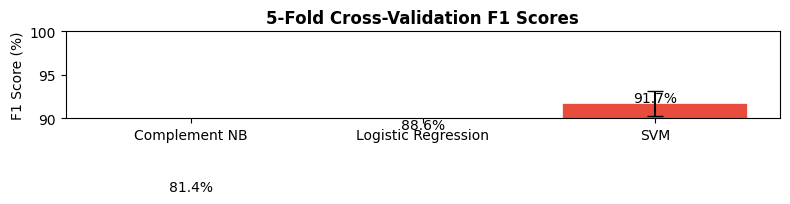

In [9]:
X_all_tfidf = tfidf.fit_transform(df['clean'].values)
y_all       = df['label_enc'].values
skf         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Complement NB'      : ComplementNB(alpha=0.3),
    'Logistic Regression': LogisticRegression(C=5, max_iter=300),
    'SVM'                : CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000)),
}

print('5-Fold CV Results (TF-IDF)\n' + '='*40)
cv_rows = []
for name, clf in cv_models.items():
    scores = cross_val_score(clf, X_all_tfidf, y_all,
                             cv=skf, scoring='f1', n_jobs=-1)
    cv_rows.append({'Model': name, 'Mean F1': scores.mean()*100,
                    'Std':   scores.std()*100})
    print(f'{name:<28}  F1: {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%')

cv_df = pd.DataFrame(cv_rows)
plt.figure(figsize=(8, 4))
bars = plt.bar(cv_df['Model'], cv_df['Mean F1'],
               yerr=cv_df['Std'], capsize=6,
               color=['#3498db','#2ecc71','#e74c3c'],
               edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, cv_df['Mean F1']):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f'{val:.1f}%', ha='center', fontsize=10)
plt.ylabel('F1 Score (%)')
plt.title('5-Fold Cross-Validation F1 Scores', fontweight='bold')
plt.ylim(90, 100)
plt.tight_layout(); plt.show()

In [10]:
best_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=8000, sublinear_tf=True)),
    ('clf',   LogisticRegression(C=5, max_iter=300))
])
best_pipeline.fit(df['clean'].values, df['label_enc'].values)
joblib.dump(best_pipeline, 'spam_classifier.pkl')
joblib.dump(le,            'label_encoder.pkl')

print('✅ Saved:')
for f in ['spam_classifier.pkl', 'label_encoder.pkl']:
    print(f'  {f}  ({os.path.getsize(f)/1024:.1f} KB)')

# Download to your computer
files.download('spam_classifier.pkl')
files.download('label_encoder.pkl')

✅ Saved:
  spam_classifier.pkl  (363.8 KB)
  label_encoder.pkl  (0.5 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
def predict_spam(message):
    cleaned  = preprocess(message)
    prob     = best_pipeline.predict_proba([cleaned])[0]
    label_id = int(prob.argmax())
    label    = le.inverse_transform([label_id])[0].upper()
    icon     = '🚫 SPAM' if label == 'SPAM' else '✅ HAM '
    return icon, prob[1]*100

test_msgs = [
    "WINNER!! You've been selected for a £500 prize. Call 09061234567 NOW!",
    "Hey, are we still on for lunch tomorrow at 1pm?",
    "Urgent! Your account is suspended. Click http://bit.ly/fix to verify.",
    "Can you pick up milk on the way home?",
    "FREE entry in 2 a weekly comp to win FA Cup final tkts. Txt FA to 87121",
    "I'll be a bit late, leaving office now.",
]

print(f"{'─'*62}")
print(f"  {'Message':<44} Result    Spam%")
print(f"{'─'*62}")
for msg in test_msgs:
    icon, spam_pct = predict_spam(msg)
    print(f"  {msg[:44]:<44} {icon}  {spam_pct:5.1f}%")
print(f"{'─'*62}")

──────────────────────────────────────────────────────────────
  Message                                      Result    Spam%
──────────────────────────────────────────────────────────────
  WINNER!! You've been selected for a £500 pri 🚫 SPAM   77.8%
  Hey, are we still on for lunch tomorrow at 1 ✅ HAM     1.0%
  Urgent! Your account is suspended. Click htt ✅ HAM    37.1%
  Can you pick up milk on the way home?        ✅ HAM     0.6%
  FREE entry in 2 a weekly comp to win FA Cup  🚫 SPAM   85.6%
  I'll be a bit late, leaving office now.      ✅ HAM     0.6%
──────────────────────────────────────────────────────────────


In [12]:

user_msg = input('\n Enter a message to classify: ')
icon, spam_pct = predict_spam(user_msg)
print(f'\nResult    : {icon}')
print(f'Spam prob : {spam_pct:.1f}%')
print(f'Ham  prob : {100-spam_pct:.1f}%')


 Enter a message to classify: hi namaskar

Result    : ✅ HAM 
Spam prob : 3.0%
Ham  prob : 97.0%
